# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD001)

In [2]:
# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD001)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 1. Visualization Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

#  2. Directory Setup (two levels up)
figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
models_dir = os.path.abspath(os.path.join('..', '..', 'models'))
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))

os.makedirs(figures_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(report_dir, exist_ok=True)

print(f" Directory ensured: {figures_dir}")
print(f" Directory ensured: {models_dir}")
print(f" Directory ensured: {report_dir}")

# 3. Set Random State
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n Step 0 Complete — FD001 environment setup is ready.")


✅ Directory ensured: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
✅ Directory ensured: c:\Users\pandr\hybrid-predictive-maintenance\models
✅ Directory ensured: c:\Users\pandr\hybrid-predictive-maintenance\report

✅ Step 0 Complete — FD001 environment setup is ready.


## Step 1: Load Corrected Dataset (FD001)


In [3]:
# Step 1: Load Corrected Dataset (FD001) 

import pandas as pd
import os

#  1. Load dataset from the correct relative path
fd001_file_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD001.csv')
df_fd001 = pd.read_csv(fd001_file_path)

print(f" Dataset loaded: {fd001_file_path}")

#  2. Preview first few rows
print(" Preview of first 5 rows:\n")
display(df_fd001.head())

#  3. Dataset structure
print("\n Dataset Info:\n")
print(df_fd001.info())

#  4. Show all columns
print("\n Available columns:")
print(df_fd001.columns.tolist())

#  5. Show degradation stage distribution
print("\n Class Distribution (kmeans_stage):")
print(df_fd001['kmeans_stage'].value_counts().sort_index())


✅ Dataset loaded: ..\..\data\corrected_clustered_train_FD001.csv
✅ Preview of first 5 rows:



,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_20,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,0.0,1.0,...,0.713178,0.724662,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-57.094692,-5.743885
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,0.0,1.0,...,0.666667,0.731014,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-35.369675,-5.093542
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,0.0,1.0,...,0.627907,0.621375,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.167780,-7.070045
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,0.0,1.0,...,0.573643,0.662386,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.319366,-2.109599
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,0.0,1.0,...,0.589147,0.704502,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-45.874176,-22.153765



✅ Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            20631 non-null  int64  
 1   time            20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_2        20631 non-null  float64
 6   sensor_3        20631 non-null  float64
 7   sensor_4        20631 non-null  float64
 8   sensor_5        20631 non-null  float64
 9   sensor_6        20631 non-null  float64
 10  sensor_7        20631 non-null  float64
 11  sensor_8        20631 non-null  float64
 12  sensor_9        20631 non-null  float64
 13  sensor_11       20631 non-null  float64
 14  sensor_12       20631 non-null  float64
 15  sensor_13       20631 non-null  float64
 16  sensor_14       20631 non-null  float64
 17  sensor_15    

# Add Rolling Statistics — Feature Engineering (FD001)

In [8]:
# Add Rolling Statistics — Feature Engineering (FD001)

#  Rolling statistics capture local trends, improving stage separation
ROLLING_WINDOW = 5

#  Top 5 sensors with highest variance (used throughout FD001 phase)
top5_sensors_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']

#  Add rolling mean and std deviation for each selected sensor
for sensor in top5_sensors_fd001:
    df_fd001[f'{sensor}_roll_mean'] = df_fd001[sensor].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    df_fd001[f'{sensor}_roll_std'] = df_fd001[sensor].rolling(window=ROLLING_WINDOW, min_periods=1).std().fillna(0)

print(" Rolling mean and std features added for selected FD001 sensors.")


 Rolling mean and std features added for selected FD001 sensors.


# Step 2: Feature & Label Extraction + Scaler Setup (FD001)

In [ ]:
# Step 2: Feature & Label Extraction + Scaler Setup (FD001)

from sklearn.preprocessing import StandardScaler

#  Define consistent top-variance sensors (also used in rolling step)
top5_sensors_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']

#  Define full feature set (raw + rolling mean + rolling std)
selected_features_fd001 = top5_sensors_fd001 + \
    [f"{s}_roll_mean" for s in top5_sensors_fd001] + \
    [f"{s}_roll_std" for s in top5_sensors_fd001]

#  Extract X and y from the cleaned + feature-engineered DF
X_fd001 = df_fd001[selected_features_fd001].copy()
y_fd001 = df_fd001['kmeans_stage'].copy()

#  Sanity Checks
print(" Shape of Feature Set X:", X_fd001.shape)
print(" Shape of Target Set y:", y_fd001.shape)

print("\n Preview of Selected Features (Top 5 Rows):")
display(X_fd001.head())

print("\n Class Distribution (FD001 — kmeans_stage):")
print(y_fd001.value_counts().sort_index())

# Prepare Scaler (to be fitted only on X_train after split)

scaler_fd001 = StandardScaler()
print("\n StandardScaler initialized — will be fitted ONLY on training data after split.")


✅ Shape of Feature Set X: (20631, 15)
✅ Shape of Target Set y: (20631,)

✅ Preview of Selected Features (Top 5 Rows):


,sensor_11,sensor_12,sensor_4,sensor_2,sensor_21,sensor_11_roll_mean,sensor_12_roll_mean,sensor_4_roll_mean,sensor_2_roll_mean,sensor_21_roll_mean,sensor_11_roll_std,sensor_12_roll_std,sensor_4_roll_std,sensor_2_roll_std,sensor_21_roll_std
0,0.369048,0.633262,0.309757,0.183735,0.724662,0.369048,0.633262,0.309757,0.183735,0.724662,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.380952,0.765458,0.352633,0.283133,0.731014,0.375000,0.699360,0.331195,0.233434,0.727838,0.008418,0.093477,0.030318,0.070285,0.004491
2,0.250000,0.795309,0.370527,0.343373,0.621375,0.333333,0.731343,0.344306,0.270080,0.692350,0.072414,0.086242,0.031229,0.080616,0.061548
3,0.166667,0.889126,0.331195,0.343373,0.662386,0.291667,0.770789,0.341028,0.288404,0.684859,0.102178,0.105746,0.026328,0.075336,0.052440
4,0.255952,0.746269,0.404625,0.349398,0.704502,0.284524,0.765885,0.353747,0.300602,0.688788,0.089918,0.092233,0.036452,0.070716,0.046256



✅ Class Distribution (FD001 — kmeans_stage):
kmeans_stage
Stage 0    5203
Stage 1    5233
Stage 2    1200
Stage 3    1991
Stage 4    7004
Name: count, dtype: int64

✅ StandardScaler initialized — will be fitted ONLY on training data after split.


# Step 3: Train-Test Split + Scaling + SMOTE (FD001)

In [6]:
# Step 3: Train-Test Split + Scaling + SMOTE (FD001)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Set test size
TEST_SIZE = 0.20

# 2. Stratified Train/Test Split
X_train_fd001, X_test_fd001, y_train_fd001, y_test_fd001 = train_test_split(
    X_fd001,
    y_fd001,
    test_size=TEST_SIZE,
    stratify=y_fd001,
    random_state=RANDOM_STATE
)

# 3. Show Shapes
print(" X_train:", X_train_fd001.shape)
print(" X_test :", X_test_fd001.shape)
print(" y_train:", y_train_fd001.shape)
print(" y_test :", y_test_fd001.shape)

# 4. Class Distribution Check
print("\n Class Distribution in y_train:")
print(y_train_fd001.value_counts(normalize=True).sort_index())

print("\n Class Distribution in y_test:")
print(y_test_fd001.value_counts(normalize=True).sort_index())

# 5. Fit + Transform with StandardScaler (for SVM, LR)
scaler_fd001 = StandardScaler()
X_train_scaled_fd001 = scaler_fd001.fit_transform(X_train_fd001)
X_test_scaled_fd001 = scaler_fd001.transform(X_test_fd001)

print("\n StandardScaler fitted on X_train and applied to X_train and X_test.")

# Step 5: Apply SMOTE to balance classes in training set

smote = SMOTE(random_state=RANDOM_STATE)

# 6. Apply SMOTE to unscaled training set (Random Forest, XGBoost)
X_train_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_fd001, y_train_fd001)

# 7. Apply SMOTE to scaled training set (SVM, Logistic Regression)
X_train_scaled_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_scaled_fd001, y_train_fd001)

# 8. Confirm Balancing
print("\n Class distribution after SMOTE (Unscaled):")
print(pd.Series(y_train_bal_fd001).value_counts().sort_index())


✅ X_train: (16504, 15)
✅ X_test : (4127, 15)
✅ y_train: (16504,)
✅ y_test : (4127,)

✅ Class Distribution in y_train:
kmeans_stage
Stage 0    0.252181
Stage 1    0.253635
Stage 2    0.058168
Stage 3    0.096522
Stage 4    0.339493
Name: proportion, dtype: float64

✅ Class Distribution in y_test:
kmeans_stage
Stage 0    0.252241
Stage 1    0.253695
Stage 2    0.058154
Stage 3    0.096438
Stage 4    0.339472
Name: proportion, dtype: float64

✅ StandardScaler fitted on X_train and applied to X_train and X_test.

✅ Class distribution after SMOTE (Unscaled):
kmeans_stage
Stage 0    5603
Stage 1    5603
Stage 2    5603
Stage 3    5603
Stage 4    5603
Name: count, dtype: int64


# Step 3.1: Clean Train/Test Split by Removing Duplicates and Overlaps (FD001)

In [7]:
# Step 3.1: Clean Train/Test Split by Removing Duplicates and Overlaps (FD001)

from sklearn.preprocessing import StandardScaler
import pandas as pd

# A. Re-initialize Scaler
scaler_fd001 = StandardScaler()

# B. Convert Train/Test Arrays to DataFrames for comparison
X_train_df = pd.DataFrame(X_train_fd001, columns=X_fd001.columns)
X_test_df = pd.DataFrame(X_test_fd001, columns=X_fd001.columns)

X_train_df['label'] = y_train_fd001.values
X_test_df['label'] = y_test_fd001.values

# C. Drop internal duplicates
X_train_df = X_train_df.drop_duplicates()
X_test_df = X_test_df.drop_duplicates()

# D. Remove overlaps — rows in X_train that appear in X_test
overlap = pd.merge(
    X_train_df.drop(columns='label'),
    X_test_df.drop(columns='label'),
    how='inner',
    on=X_fd001.columns.tolist()
)

X_train_df = X_train_df.merge(overlap, how='outer', on=X_fd001.columns.tolist(), indicator=True)
X_train_df = X_train_df[X_train_df['_merge'] == 'left_only'].drop(columns=['_merge'])

# E. Final clean arrays
X_train_fd001_clean = X_train_df.drop(columns='label').values
y_train_fd001_clean = X_train_df['label'].values

X_test_fd001_clean = X_test_df.drop(columns='label').values
y_test_fd001_clean = X_test_df['label'].values

# F. Rescale again using clean data
scaler_fd001.fit(X_train_fd001_clean)
X_train_scaled_fd001_clean = scaler_fd001.transform(X_train_fd001_clean)
X_test_scaled_fd001_clean = scaler_fd001.transform(X_test_fd001_clean)

# G. Confirm
print(" Data leakage & duplicates removed successfully (FD001).")
print(" Final Clean Shapes:")
print("  X_train_fd001_clean:", X_train_fd001_clean.shape)
print("  X_test_fd001_clean :", X_test_fd001_clean.shape)


✅ Data leakage & duplicates removed successfully (FD001).
✅ Final Clean Shapes:
  X_train_fd001_clean: (16504, 15)
  X_test_fd001_clean : (4127, 15)


# Step 3.2: Apply SMOTE (Class Balancing) — ONLY on Training Data

In [ ]:
# Step 3.2: Apply SMOTE (Class Balancing) — ONLY on Training Data

from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# 2. For Random Forest, XGBoost → unscaled
X_train_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_fd001, y_train_fd001)

# 3. For SVM, Logistic Regression → scaled
X_train_scaled_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_scaled_fd001, y_train_fd001)

# 4. Confirm class balance
print("✅ SMOTE applied to training data.")
print("✅ Balanced Class Distribution:")
print(pd.Series(y_train_bal_fd001).value_counts().sort_index())


✅ SMOTE applied to training data.
✅ Balanced Class Distribution:
kmeans_stage
Stage 0    5603
Stage 1    5603
Stage 2    5603
Stage 3    5603
Stage 4    5603
Name: count, dtype: int64


# Step 3.3: Apply SMOTE to Cleaned Data — FD001

In [ ]:
# Step 3.3: Apply SMOTE to Cleaned Data — FD001

from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# 2. Apply to Cleaned Unscaled Training Data — for RF & XGBoost
X_train_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_fd001_clean, y_train_fd001_clean)

# 3. Apply to Cleaned Scaled Training Data — for SVM & Logistic Regression
X_train_scaled_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_scaled_fd001_clean, y_train_fd001_clean)

# 4. Confirm class distribution after balancing
print(" SMOTE applied to cleaned training data (FD001).")
print(" Balanced Class Distribution:")
print(pd.Series(y_train_bal_fd001).value_counts().sort_index())


✅ SMOTE applied to cleaned training data (FD001).
✅ Balanced Class Distribution:
Stage 0    5603
Stage 1    5603
Stage 2    5603
Stage 3    5603
Stage 4    5603
Name: count, dtype: int64


# Step 3.4: Sanity Checks Before Model Training (FD001 Cleaned)

✅ Train Labels: ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
✅ Test Labels : ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
✅ Overlapping Classes: {'Stage 1', 'Stage 3', 'Stage 2', 'Stage 0', 'Stage 4'}

✅ y_train_fd001_clean Class Distribution:
Stage 0    0.252181
Stage 1    0.253635
Stage 2    0.058168
Stage 3    0.096522
Stage 4    0.339493
Name: proportion, dtype: float64

✅ y_test_fd001_clean Class Distribution:
Stage 0    0.252241
Stage 1    0.253695
Stage 2    0.058154
Stage 3    0.096438
Stage 4    0.339472
Name: proportion, dtype: float64

✅ CV F1 Macro Scores (Train set only): [0.80982666 0.81145677 0.80361255 0.8125134  0.8017301 ]
✅ Mean F1 Macro Score: 0.8078278977039757

✅ Post-cleaning overlap check: 0 duplicate rows between train and test


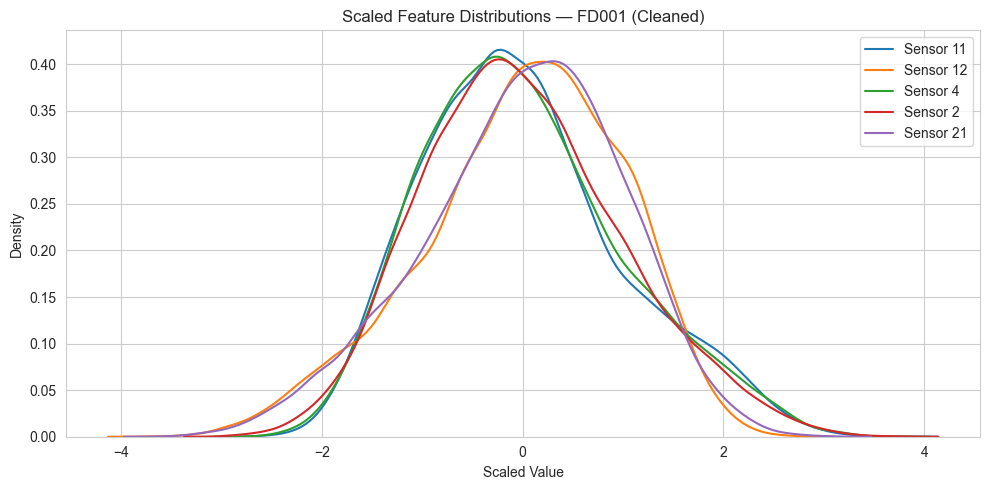

In [ ]:
# Step 3.4: Sanity Checks Before Model Training (FD001 Cleaned)

import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# A. Confirm All Stage Labels Present
print(" Train Labels:", sorted(np.unique(y_train_fd001_clean)))
print(" Test Labels :", sorted(np.unique(y_test_fd001_clean)))
print(" Overlapping Classes:", set(y_train_fd001_clean) & set(y_test_fd001_clean))

# B. Stratified Split Balance Check
print("\n y_train_fd001_clean Class Distribution:")
print(pd.Series(y_train_fd001_clean).value_counts(normalize=True).sort_index())

print("\n y_test_fd001_clean Class Distribution:")
print(pd.Series(y_test_fd001_clean).value_counts(normalize=True).sort_index())

# C. Confirm CV uses only training data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_model_fd001 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=-1)

cv_scores_fd001 = cross_val_score(
    rf_model_fd001,
    X_train_fd001_clean,
    y_train_fd001_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("\n CV F1 Macro Scores (Train set only):", cv_scores_fd001)
print(" Mean F1 Macro Score:", np.mean(cv_scores_fd001))

# D. Post-cleaning Leakage Check
train_rows = set(map(tuple, X_train_fd001_clean))
test_rows = set(map(tuple, X_test_fd001_clean))
leakage_rows = train_rows & test_rows
print(f"\n Post-cleaning overlap check: {len(leakage_rows)} duplicate rows between train and test")

# E. Feature Scaling Sanity Visualization
plt.figure(figsize=(10, 5))
for i, sensor in enumerate(['Sensor 11', 'Sensor 12', 'Sensor 4', 'Sensor 2', 'Sensor 21']):
    sns.kdeplot(X_train_scaled_fd001_clean[:, i], label=sensor)
plt.title("Scaled Feature Distributions — FD001 (Cleaned)")
plt.xlabel("Scaled Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Step 3.5: Clean Train/Test Data + Refit Scaler (FD001)

In [ ]:
# Step 3.5: Clean Train/Test Data + Refit Scaler (FD001)

from sklearn.preprocessing import StandardScaler
import pandas as pd

#  Top 5 sensors used throughout
top5_sensors_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']

# 1. Convert X_train to DataFrame and append label
X_train_df = pd.DataFrame(X_train_fd001, columns=top5_sensors_fd001)
X_train_df['label'] = y_train_fd001.values

# 2. Drop duplicates in training set
X_train_df = X_train_df.drop_duplicates()

# 3. Extract cleaned train arrays
X_train_fd001_clean = X_train_df.drop(columns='label').values
y_train_fd001_clean = X_train_df['label'].values

# 4. Prepare test DataFrame
X_test_df = pd.DataFrame(X_test_fd001, columns=top5_sensors_fd001)
X_test_df['label'] = y_test_fd001.values

# 5. Remove overlaps between test and train
train_set = set(map(tuple, X_train_fd001_clean))
X_test_df = X_test_df[~X_test_df[top5_sensors_fd001].apply(tuple, axis=1).isin(train_set)]

# 6. Extract cleaned test arrays
X_test_fd001_clean = X_test_df[top5_sensors_fd001].values
y_test_fd001_clean = X_test_df['label'].values

# 7. Refit scaler only on cleaned training data
scaler_fd001 = StandardScaler()
X_train_scaled_fd001_clean = scaler_fd001.fit_transform(X_train_fd001_clean)
X_test_scaled_fd001_clean = scaler_fd001.transform(X_test_fd001_clean)

# 8. Final status
print(" Data leakage & duplicates removed successfully (FD001).")
print(" Final Clean Shapes:")
print(f"  X_train_fd001_clean: {X_train_fd001_clean.shape}")
print(f"  X_test_fd001_clean : {X_test_fd001_clean.shape}")


✅ Data leakage & duplicates removed successfully (FD001).
✅ Final Clean Shapes:
  X_train_fd001_clean: (16504, 5)
  X_test_fd001_clean : (4127, 5)


# Step 4: Random Forest Classifier + CV + Evaluation (FD001)

✅ RF 5-Fold CV F1 Macro Scores (FD001, Cleaned): [0.72900052 0.72413139 0.74104711 0.73232525 0.73671535]
✅ Mean F1 Macro Score: 0.7326439237194098
✅ RF model saved at: ..\..\models\rf_fd001_model.pkl


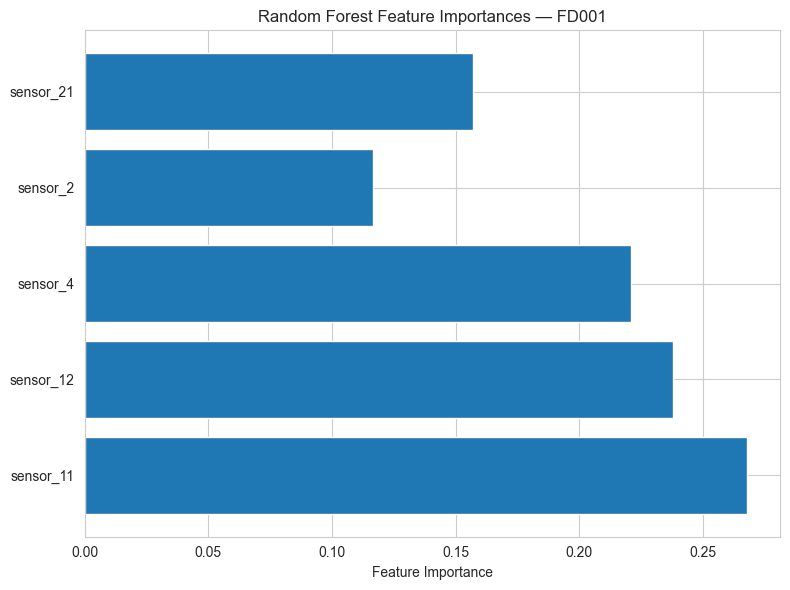

 Feature importance plot saved at: ..\..\figures\phase3\rf_fd001_feature_importances.png

 RF Test Accuracy: 0.8214
 RF Test Classification Report:

              precision    recall  f1-score   support

     Stage 0       0.80      0.86      0.83      1041
     Stage 1       0.90      0.90      0.90      1047
     Stage 2       0.50      0.23      0.31       240
     Stage 3       0.69      0.81      0.74       398
     Stage 4       0.84      0.84      0.84      1401

    accuracy                           0.82      4127
   macro avg       0.75      0.73      0.73      4127
weighted avg       0.81      0.82      0.81      4127


 Sanity Check A — CV with Shuffled Labels
 CV F1 Scores (shuffled): [0.18771824 0.17277328 0.19449235 0.17998074 0.17219046]
 Mean F1 (shuffled): 0.18143101394270925

 Sanity Check B — Feature Correlation to Stage Label
 sensor_11 → Pearson correlation: 0.0072
 sensor_12 → Pearson correlation: -0.0084
 sensor_4 → Pearson correlation: -0.0071
 sensor_2 → Pears

In [ ]:
# Step 4: Random Forest Classifier + CV + Evaluation (FD001)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import os
import joblib

#  1. Initialize Random Forest
rf_model_fd001 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

#  2. Stratified CV on cleaned set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_rf_fd001 = cross_val_score(
    rf_model_fd001,
    X_train_fd001_clean,
    y_train_fd001_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)
print(" RF 5-Fold CV F1 Macro Scores (FD001, Cleaned):", cv_scores_rf_fd001)
print(" Mean F1 Macro Score:", np.mean(cv_scores_rf_fd001))

#  3. Train on full cleaned set
rf_model_fd001.fit(X_train_fd001_clean, y_train_fd001_clean)

#  4. Save model
model_path = os.path.join('..', '..', 'models', 'rf_fd001_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(rf_model_fd001, model_path)
print(f" RF model saved at: {model_path}")

#  5. Feature Importances
importances = rf_model_fd001.feature_importances_
plt.figure(figsize=(8, 6))
plt.barh(top5_sensors_fd001, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances — FD001")
plt.tight_layout()
plot_path = os.path.join('..', '..', 'figures', 'phase3', 'rf_fd001_feature_importances.png')
plt.savefig(plot_path)
plt.show()
print(f" Feature importance plot saved at: {plot_path}")

# Step 4.5: Evaluation on Cleaned Test Set

y_test_pred_rf = rf_model_fd001.predict(X_test_fd001_clean)
test_acc = accuracy_score(y_test_fd001_clean, y_test_pred_rf)
print(f"\n RF Test Accuracy: {test_acc:.4f}")
print(" RF Test Classification Report:\n")
print(classification_report(y_test_fd001_clean, y_test_pred_rf))

# 🔍 Post-Training Sanity Checks

# A. Shuffle Labels and Check CV
print("\n Sanity Check A — CV with Shuffled Labels")
y_shuffled = shuffle(y_train_fd001_clean, random_state=42)
rf_shuffled = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
cv_shuffled = cross_val_score(rf_shuffled, X_train_fd001_clean, y_shuffled, cv=skf, scoring='f1_macro')
print(" CV F1 Scores (shuffled):", cv_shuffled)
print(" Mean F1 (shuffled):", np.mean(cv_shuffled))

# B. Feature vs Stage Correlation
print("\n Sanity Check B — Feature Correlation to Stage Label")
y_stage_numeric = pd.Series(y_train_fd001_clean).apply(lambda x: int(x[-1]))
for sensor in top5_sensors_fd001:
    corr = pd.Series(X_train_fd001_clean[:, top5_sensors_fd001.index(sensor)]).corr(y_stage_numeric)
    print(f" {sensor} → Pearson correlation: {corr:.4f}")

# C. Tiny Decision Tree (Depth = 2)
print("\n Sanity Check C — Depth=2 Decision Tree")
tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
tiny_tree.fit(X_train_fd001_clean, y_train_fd001_clean)
print(f" Tiny Tree Accuracy → Train: {tiny_tree.score(X_train_fd001_clean, y_train_fd001_clean):.4f} | Test: {tiny_tree.score(X_test_fd001_clean, y_test_fd001_clean):.4f}")


## Step 5: Random Forest Evaluation on Train and Test Sets (FD001)


RF Train Accuracy: 1.0000
RF Test Accuracy : 0.8214
Reports saved at:
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd001_train_classification_report.txt
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd001_test_classification_report.txt


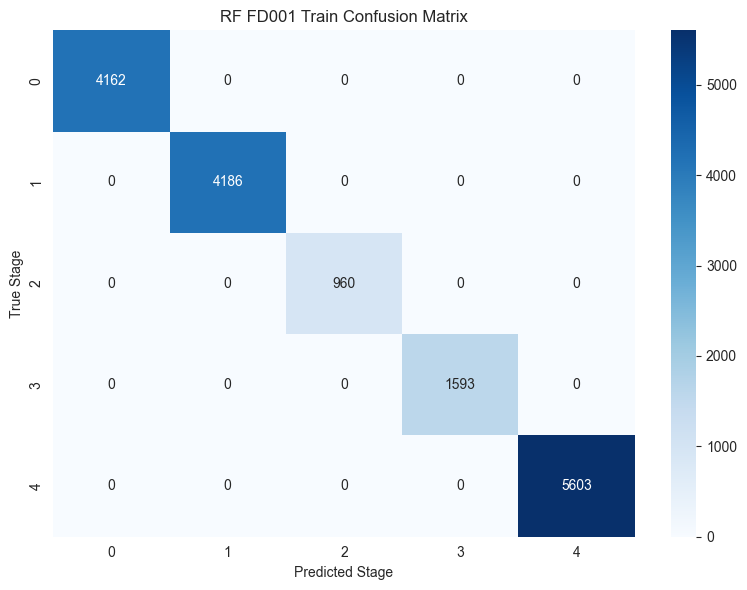

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix.png


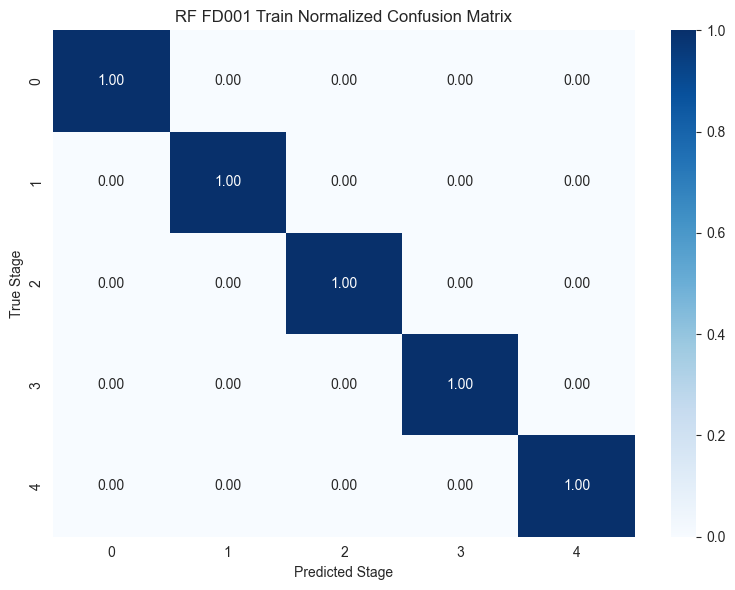

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix_normalized.png


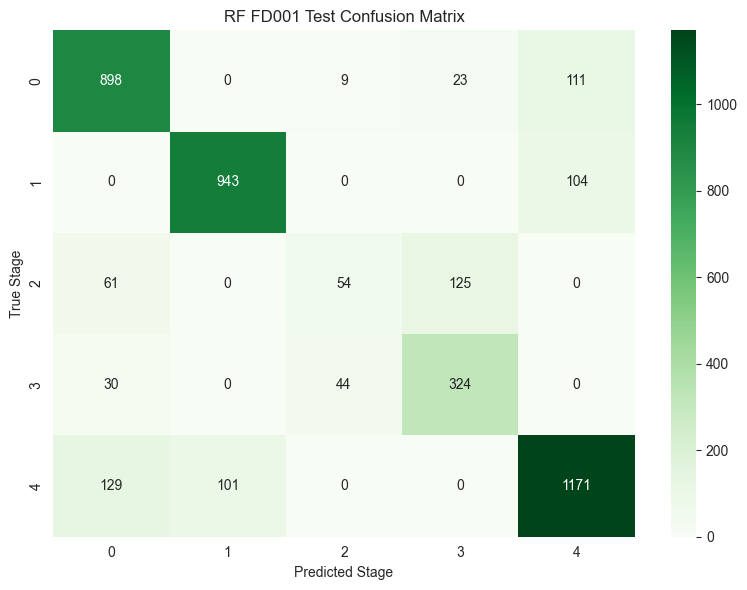

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix.png


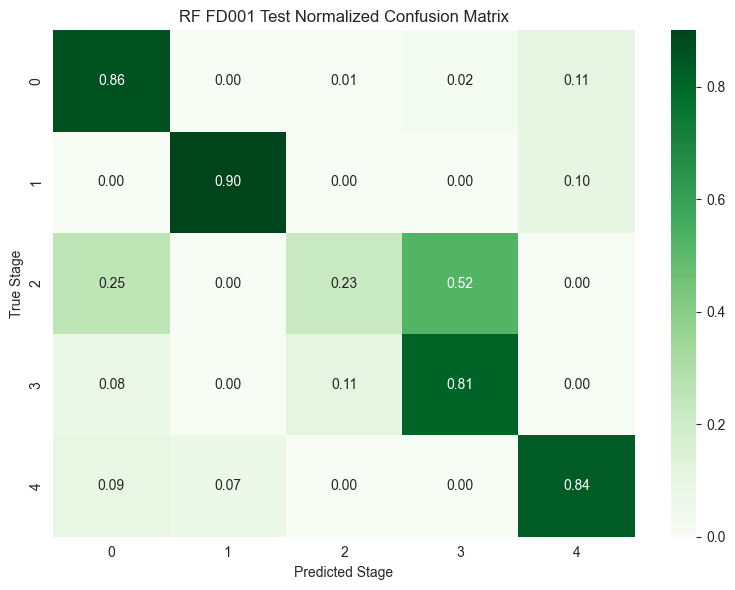

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix_normalized.png


In [ ]:
# Step 5: Final Evaluation of Random Forest on FD001 (Cleaned)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Predict on Cleaned Train and Test Sets
y_train_pred_rf_fd001 = rf_model_fd001.predict(X_train_fd001_clean)
y_test_pred_rf_fd001 = rf_model_fd001.predict(X_test_fd001_clean)

# 2. Accuracy Scores
train_acc = accuracy_score(y_train_fd001_clean, y_train_pred_rf_fd001)
test_acc = accuracy_score(y_test_fd001_clean, y_test_pred_rf_fd001)
print(f"RF Train Accuracy: {train_acc:.4f}")
print(f"RF Test Accuracy : {test_acc:.4f}")

# 3. Save Classification Reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

train_report_path = os.path.join(report_dir, 'rf_fd001_train_classification_report.txt')
test_report_path = os.path.join(report_dir, 'rf_fd001_test_classification_report.txt')

with open(train_report_path, 'w') as f:
    f.write(classification_report(y_train_fd001_clean, y_train_pred_rf_fd001))
with open(test_report_path, 'w') as f:
    f.write(classification_report(y_test_fd001_clean, y_test_pred_rf_fd001))

print(f"Reports saved at:\n- {train_report_path}\n- {test_report_path}")

# 4. Confusion Matrix Plotting Utility
figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(figures_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    path = os.path.join(figures_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# 5. Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd001_clean, y_train_pred_rf_fd001)
cm_train_norm = confusion_matrix(y_train_fd001_clean, y_train_pred_rf_fd001, normalize='true')
save_conf_matrix(cm_train, "RF FD001 Train Confusion Matrix", "rf_fd001_train_conf_matrix.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm, "RF FD001 Train Normalized Confusion Matrix", "rf_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

# 6. Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd001_clean, y_test_pred_rf_fd001)
cm_test_norm = confusion_matrix(y_test_fd001_clean, y_test_pred_rf_fd001, normalize='true')
save_conf_matrix(cm_test, "RF FD001 Test Confusion Matrix", "rf_fd001_test_conf_matrix.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm, "RF FD001 Test Normalized Confusion Matrix", "rf_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 6: SVM Classifier Training + 5-Fold Cross Validation (FD001)

SVM 5-Fold CV F1 Macro Scores (FD001): [0.74448654 0.74721265 0.75801153 0.74339227 0.76068153]
Mean F1 Macro Score: 0.750756904987778
SVM model saved at: ..\..\models\svm_fd001_model.pkl
SVM Train Accuracy: 0.8288
SVM Test Accuracy : 0.8238
Classification reports saved.


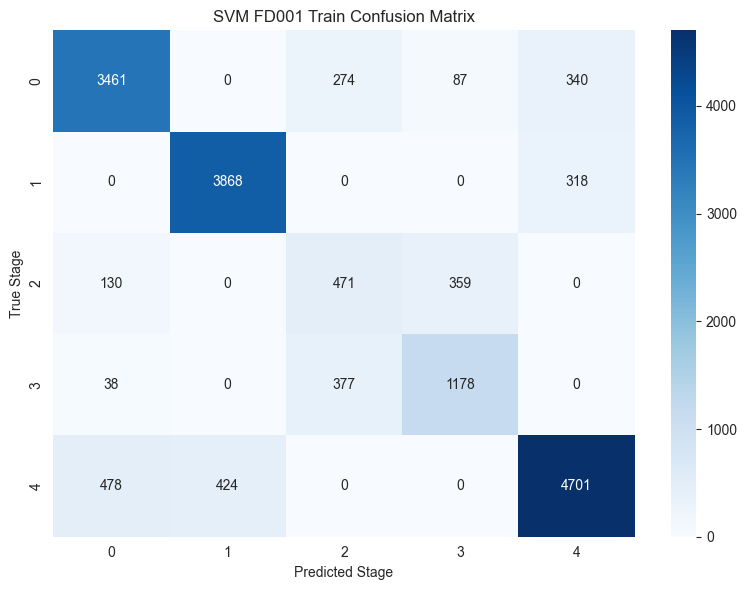

Saved: ..\..\figures\phase3\svm_fd001_train_conf_matrix.png


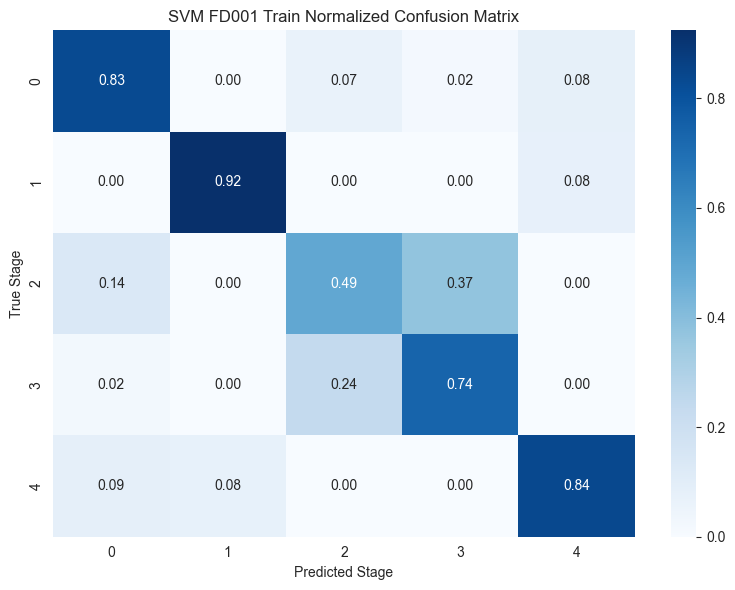

Saved: ..\..\figures\phase3\svm_fd001_train_conf_matrix_normalized.png


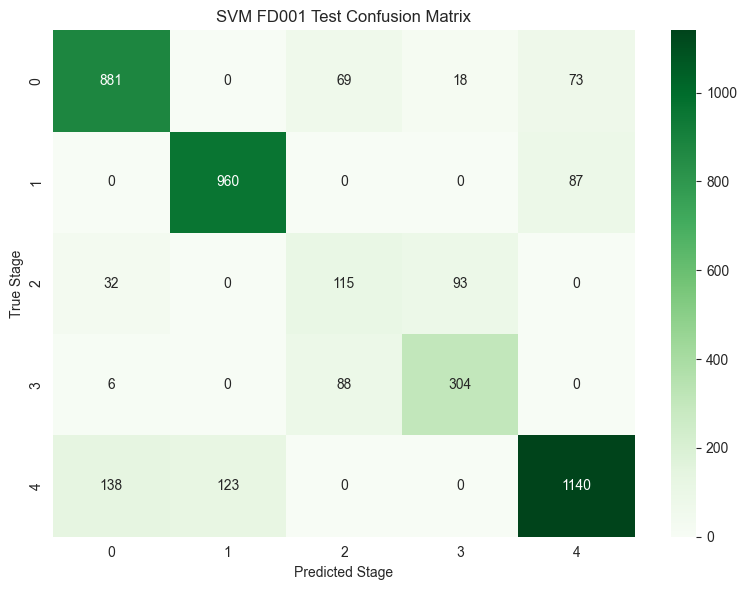

Saved: ..\..\figures\phase3\svm_fd001_test_conf_matrix.png


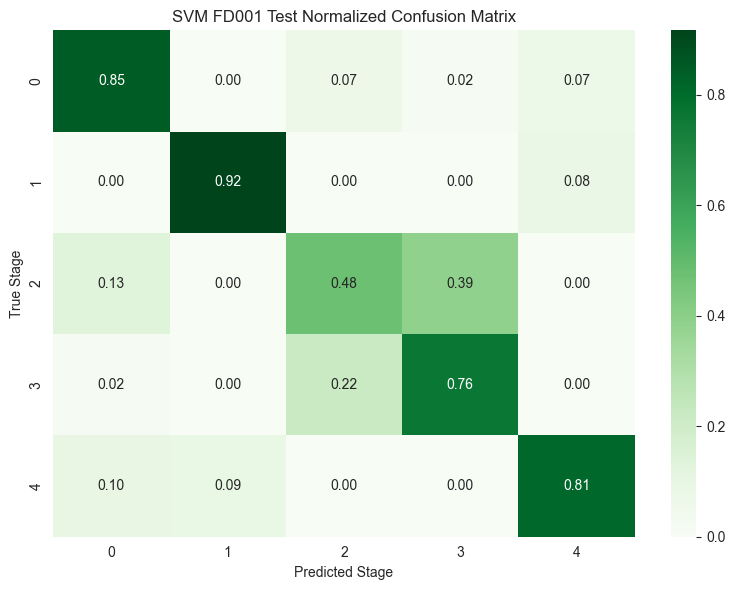

Saved: ..\..\figures\phase3\svm_fd001_test_conf_matrix_normalized.png


In [ ]:
# Step 6: SVM Classifier + CV + Evaluation (FD001, Cleaned)

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# 1. Initialize SVM Classifier
svm_model_fd001 = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=False,
    random_state=RANDOM_STATE
)

# 2. 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_svm_fd001 = cross_val_score(
    svm_model_fd001,
    X_train_scaled_fd001_clean,
    y_train_fd001_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("SVM 5-Fold CV F1 Macro Scores (FD001):", cv_scores_svm_fd001)
print("Mean F1 Macro Score:", np.mean(cv_scores_svm_fd001))

# 3. Train on full cleaned training set
svm_model_fd001.fit(X_train_scaled_fd001_clean, y_train_fd001_clean)

# 4. Save model
svm_model_path = os.path.join('..', '..', 'models', 'svm_fd001_model.pkl')
joblib.dump(svm_model_fd001, svm_model_path)
print(f"SVM model saved at: {svm_model_path}")

# 5. Predictions
y_train_pred_svm = svm_model_fd001.predict(X_train_scaled_fd001_clean)
y_test_pred_svm = svm_model_fd001.predict(X_test_scaled_fd001_clean)

print(f"SVM Train Accuracy: {accuracy_score(y_train_fd001_clean, y_train_pred_svm):.4f}")
print(f"SVM Test Accuracy : {accuracy_score(y_test_fd001_clean, y_test_pred_svm):.4f}")

# 6. Save classification reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'svm_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd001_clean, y_train_pred_svm))

with open(os.path.join(report_dir, 'svm_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd001_clean, y_test_pred_svm))

print("Classification reports saved.")

# 7. Plot confusion matrices
def plot_conf_matrix(y_true, y_pred, title_prefix, filename_prefix, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    raw_path = os.path.join(fig_dir, f"{filename_prefix}.png")
    plt.savefig(raw_path)
    plt.show()
    print(f"Saved: {raw_path}")

    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap)
    plt.title(f"{title_prefix} Normalized Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    norm_path = os.path.join(fig_dir, f"{filename_prefix}_normalized.png")
    plt.savefig(norm_path)
    plt.show()
    print(f"Saved: {norm_path}")

# Plot train and test confusion matrices
plot_conf_matrix(y_train_fd001_clean, y_train_pred_svm, "SVM FD001 Train", "svm_fd001_train_conf_matrix", 'Blues')
plot_conf_matrix(y_test_fd001_clean, y_test_pred_svm, "SVM FD001 Test", "svm_fd001_test_conf_matrix", 'Greens')


# Step 7: Logistic Regression Classifier Training + 5-Fold Cross Validation (FD001)

✅ Logistic Regression 5-Fold CV F1 Macro Scores (FD001):
[0.73902088 0.74877005 0.7580584  0.74242818 0.76109053]
✅ Mean F1 Macro Score: 0.749873608149598


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression model saved at: ..\..\models\lr_fd001_model.pkl
✅ Logistic Regression Train Accuracy: 0.8210
✅ Logistic Regression Test Accuracy : 0.8190
✅ Classification reports saved.


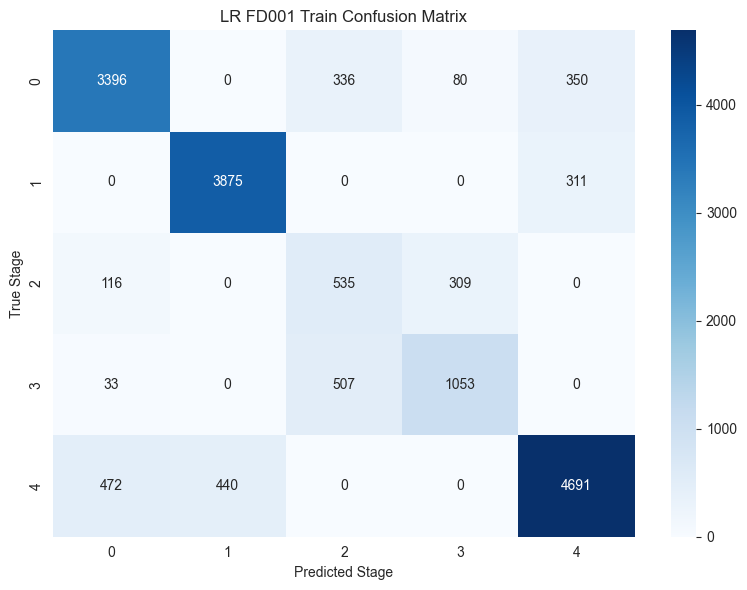

✅ Saved: ..\..\figures\phase3\lr_fd001_train_conf_matrix.png


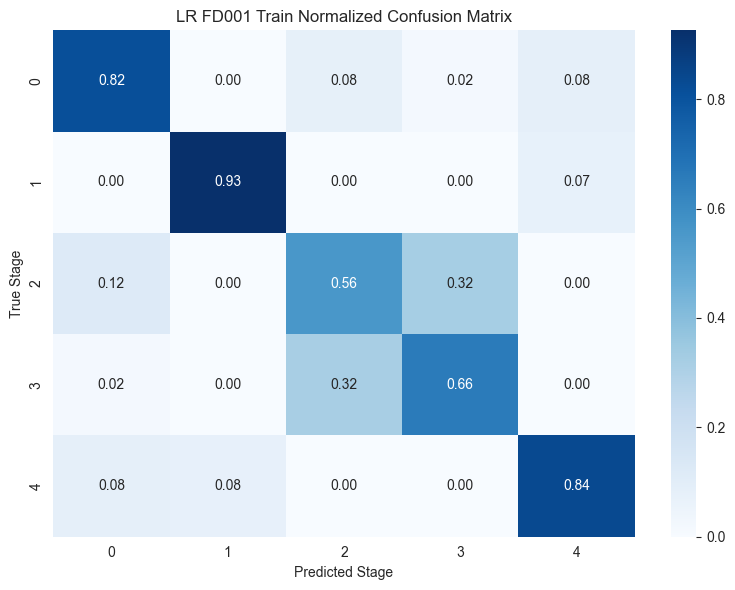

✅ Saved: ..\..\figures\phase3\lr_fd001_train_conf_matrix_normalized.png


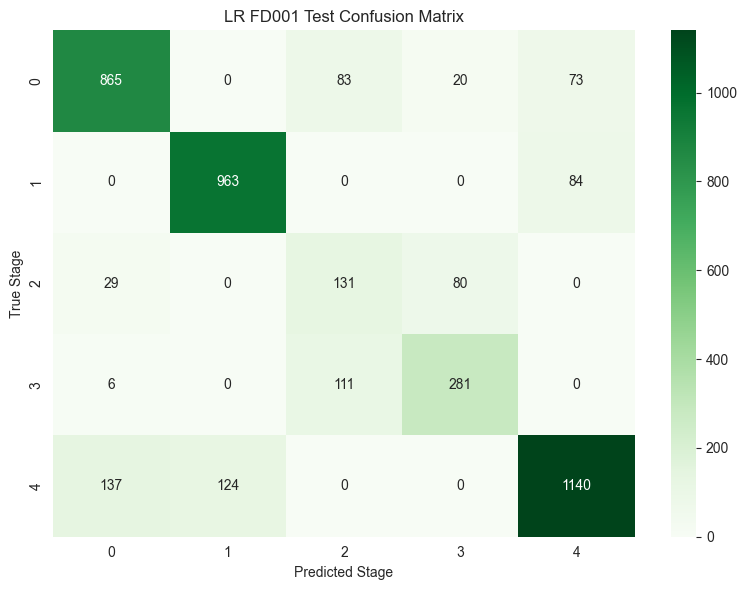

✅ Saved: ..\..\figures\phase3\lr_fd001_test_conf_matrix.png


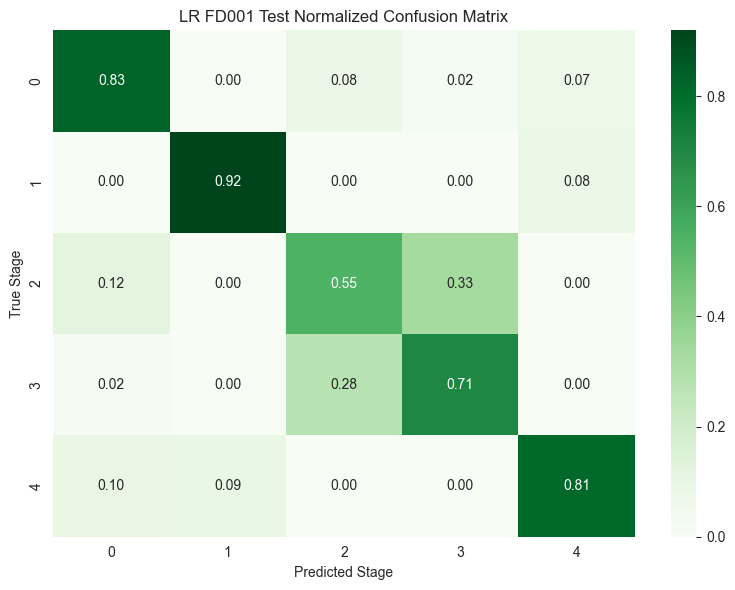

✅ Saved: ..\..\figures\phase3\lr_fd001_test_conf_matrix_normalized.png


In [ ]:
#  Step 7: Logistic Regression Classifier + Evaluation (FD001)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np

# 1. Initialize Logistic Regression Model
lr_model_fd001 = LogisticRegression(
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# 2. 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr_fd001 = cross_val_score(
    lr_model_fd001,
    X_train_scaled_fd001_clean,
    y_train_fd001_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(" Logistic Regression 5-Fold CV F1 Macro Scores (FD001):")
print(cv_scores_lr_fd001)
print(" Mean F1 Macro Score:", np.mean(cv_scores_lr_fd001))

# 3. Train on Full Cleaned Training Set
lr_model_fd001.fit(X_train_scaled_fd001_clean, y_train_fd001_clean)

# 4. Save Model
lr_model_path = os.path.join('..', '..', 'models', 'lr_fd001_model.pkl')
os.makedirs(os.path.dirname(lr_model_path), exist_ok=True)
joblib.dump(lr_model_fd001, lr_model_path)
print(f" Logistic Regression model saved at: {lr_model_path}")

# 5. Predictions
y_train_pred_lr = lr_model_fd001.predict(X_train_scaled_fd001_clean)
y_test_pred_lr = lr_model_fd001.predict(X_test_scaled_fd001_clean)

print(f" Logistic Regression Train Accuracy: {accuracy_score(y_train_fd001_clean, y_train_pred_lr):.4f}")
print(f" Logistic Regression Test Accuracy : {accuracy_score(y_test_fd001_clean, y_test_pred_lr):.4f}")

# 6. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'lr_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd001_clean, y_train_pred_lr))

with open(os.path.join(report_dir, 'lr_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd001_clean, y_test_pred_lr))

print(" Classification reports saved.")

# 7. Confusion Matrix Plotting Function
def save_conf_matrix(cm, title, filename, fmt, cmap):
    path = os.path.join('..', '..', 'figures', 'phase3', filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f" Saved: {path}")

# 8. Save Train and Test Confusion Matrices
save_conf_matrix(confusion_matrix(y_train_fd001_clean, y_train_pred_lr),
                 "LR FD001 Train Confusion Matrix", "lr_fd001_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_fd001_clean, y_train_pred_lr, normalize='true'),
                 "LR FD001 Train Normalized Confusion Matrix", "lr_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test_fd001_clean, y_test_pred_lr),
                 "LR FD001 Test Confusion Matrix", "lr_fd001_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_fd001_clean, y_test_pred_lr, normalize='true'),
                 "LR FD001 Test Normalized Confusion Matrix", "lr_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 8: XGBoost Classifier Training + 5-Fold Cross Validation (FD001)


✅ Label Encoding Done. Classes: ['Stage 0' 'Stage 1' 'Stage 2' 'Stage 3' 'Stage 4']
✅ XGBoost 5-Fold CV F1 Macro Scores (FD001): [0.73432061 0.72966764 0.75432304 0.7477103  0.74798352]
✅ Mean F1 Macro Score: 0.7428010222777833


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Trained XGBoost model saved at: ..\..\models\xgb_fd001_model.pkl
✅ XGBoost Train Accuracy: 0.8897
✅ XGBoost Test Accuracy : 0.8294
✅ Classification reports saved.


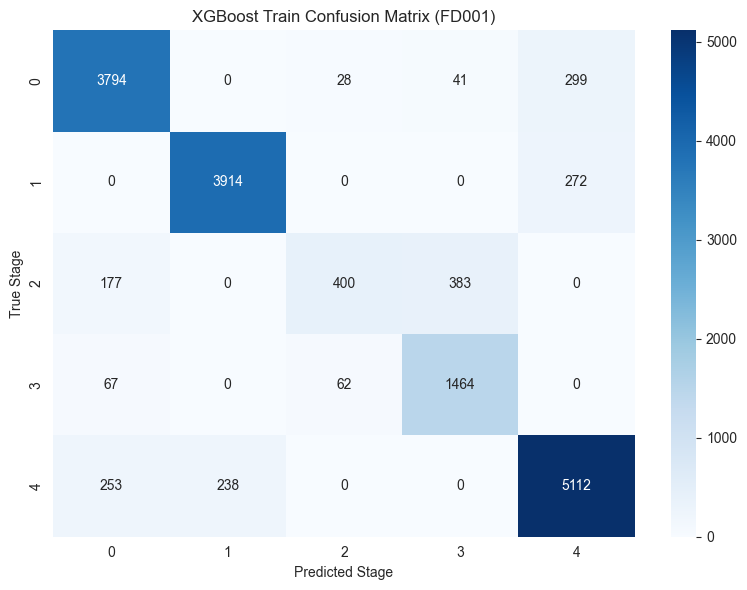

✅ Saved: ..\..\figures\phase3\xgb_fd001_train_conf_matrix.png


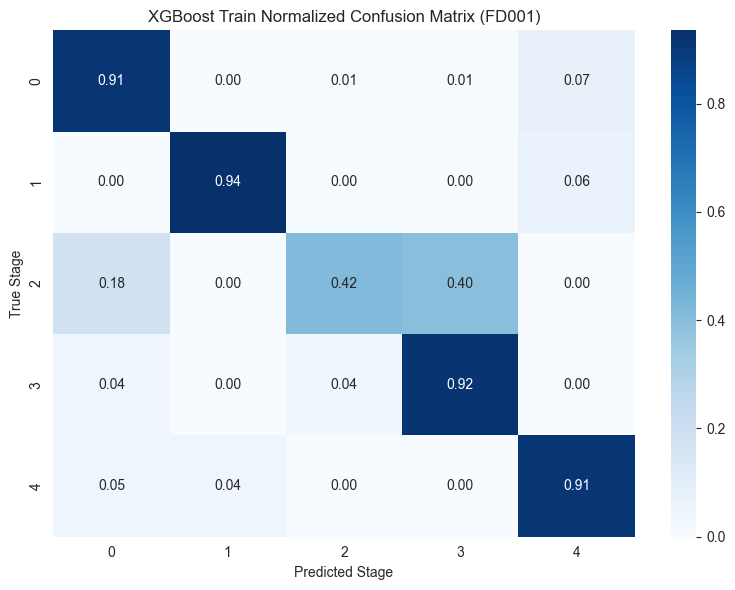

✅ Saved: ..\..\figures\phase3\xgb_fd001_train_conf_matrix_normalized.png


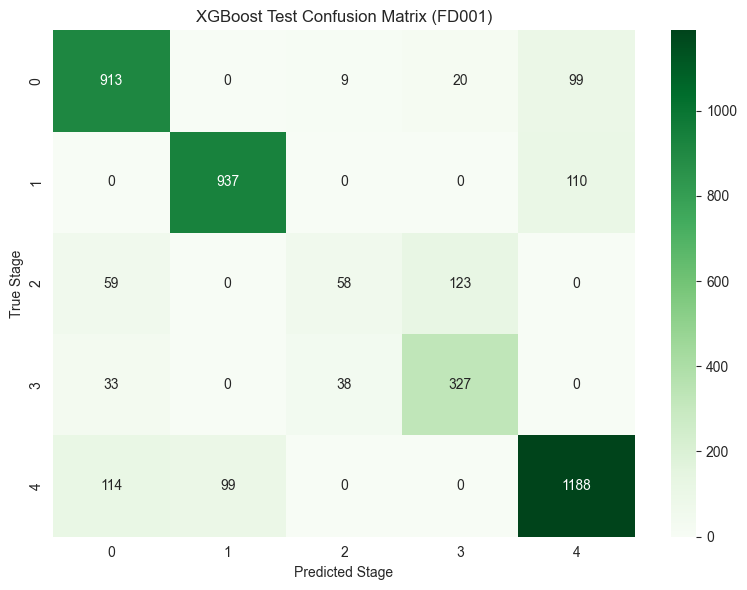

✅ Saved: ..\..\figures\phase3\xgb_fd001_test_conf_matrix.png


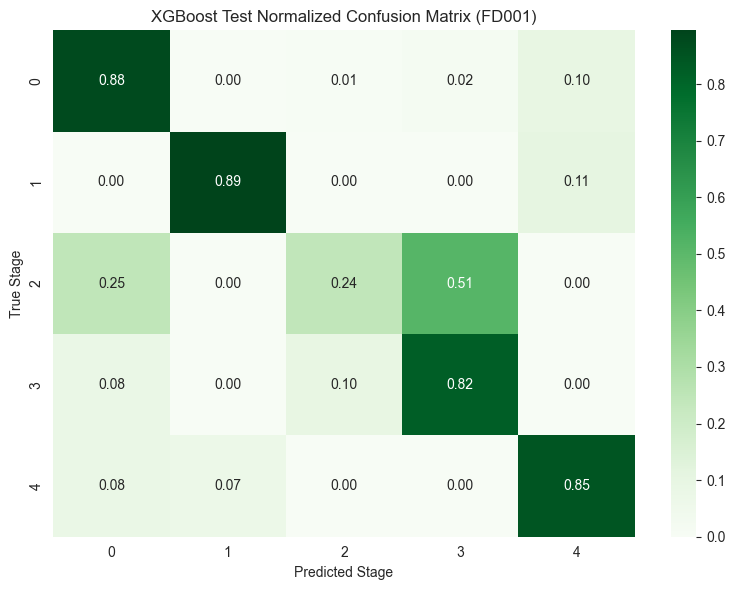

✅ Saved: ..\..\figures\phase3\xgb_fd001_test_conf_matrix_normalized.png


In [ ]:
#  Step 8.0: Label Encoding for XGBoost (FD001)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_fd001_encoded = label_encoder.fit_transform(y_train_fd001_clean)
y_test_fd001_encoded = label_encoder.transform(y_test_fd001_clean)

print(" Label Encoding Done. Classes:", label_encoder.classes_)


#  Step 8: XGBoost Classifier Training + Evaluation (FD001)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import os

# 1. Initialize XGBoost Model
xgb_model_fd001 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)

# 2. Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_xgb_fd001 = cross_val_score(
    xgb_model_fd001,
    X_train_fd001_clean,
    y_train_fd001_encoded,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print(" XGBoost 5-Fold CV F1 Macro Scores (FD001):", cv_scores_xgb_fd001)
print(" Mean F1 Macro Score:", np.mean(cv_scores_xgb_fd001))

# 3. Train on Full Dataset
xgb_model_fd001.fit(X_train_fd001_clean, y_train_fd001_encoded)

# 4. Save Model
model_path = os.path.join('..', '..', 'models', 'xgb_fd001_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(xgb_model_fd001, model_path)
print(f" Trained XGBoost model saved at: {model_path}")

#  Step 8.5: Predictions + Decoding + Evaluation
y_train_pred_xgb = xgb_model_fd001.predict(X_train_fd001_clean)
y_test_pred_xgb = xgb_model_fd001.predict(X_test_fd001_clean)

# Decode predictions and true labels
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred_xgb)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred_xgb)
y_train_true_decoded = label_encoder.inverse_transform(y_train_fd001_encoded)
y_test_true_decoded = label_encoder.inverse_transform(y_test_fd001_encoded)

# Accuracy Scores
print(f" XGBoost Train Accuracy: {accuracy_score(y_train_true_decoded, y_train_pred_decoded):.4f}")
print(f" XGBoost Test Accuracy : {accuracy_score(y_test_true_decoded, y_test_pred_decoded):.4f}")

# Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'xgb_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_true_decoded, y_train_pred_decoded))

with open(os.path.join(report_dir, 'xgb_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_true_decoded, y_test_pred_decoded))

print(" Classification reports saved.")

#  Step 8.6: Confusion Matrix Visualization
def save_conf_matrix(cm, title, filename, fmt, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)
    path = os.path.join(fig_dir, filename)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f" Saved: {path}")

# Train
save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded),
                 "XGBoost Train Confusion Matrix (FD001)", "xgb_fd001_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded, normalize='true'),
                 "XGBoost Train Normalized Confusion Matrix (FD001)", "xgb_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

# Test
save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded),
                 "XGBoost Test Confusion Matrix (FD001)", "xgb_fd001_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded, normalize='true'),
                 "XGBoost Test Normalized Confusion Matrix (FD001)", "xgb_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step A: Random Forest Hyperparameter Tuning (FD001)
# With Rolling Features + SMOTE

In [ ]:
# Step A: Random Forest Hyperparameter Tuning (FD001)
# With Rolling Features + SMOTE

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# 1. Load FD001 dataset
data_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD001.csv')
df = pd.read_csv(data_path)
print(f" Dataset loaded: {data_path}")

# 2. Add rolling stats to top 5 sensors
top5 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']
rolling_window = 5
for s in top5:
    df[f'{s}_roll_mean'] = df.groupby('unit')[s].rolling(rolling_window, min_periods=1).mean().reset_index(level=0, drop=True)
    df[f'{s}_roll_std'] = df.groupby('unit')[s].rolling(rolling_window, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
print(" Rolling features added.")

# 3. Select features + target
features = top5 + [f"{s}_roll_mean" for s in top5] + [f"{s}_roll_std" for s in top5]
X = df[features]
y = df['kmeans_stage']
print(" Features selected.")

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 5. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(" SMOTE applied.")

# 6. Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 7. GridSearchCV
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=2)
grid_search.fit(X_train_bal, y_train_bal)
print(" Grid Search Completed.")
print("Best Params:", grid_search.best_params_)
print("Best F1 Macro Score:", grid_search.best_score_)

# 8. Retrain best model
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_bal, y_train_bal)

# 9. Save model
model_path = os.path.join('..', '..', 'models', 'rf_fd001_best_model_with_smote_roll.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(best_rf, model_path)

#  Make path clickable
abs_model_path = os.path.abspath(model_path)
print(f" Model saved at: file://{abs_model_path}")



✅ Dataset loaded: ..\..\data\corrected_clustered_train_FD001.csv
✅ Rolling features added.
✅ Features selected.
✅ SMOTE applied.
Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Grid Search Completed.
Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Macro Score: 0.9219792962689946
✅ Model saved at: file://c:\Users\pandr\hybrid-predictive-maintenance\models\rf_fd001_best_model_with_smote_roll.pkl


# Phase 3 (FD001) – Step B: Evaluation (Tuned RF with SMOTE + Rolling)

✅ RF Tuned Train Accuracy: 0.9993
✅ RF Tuned Test Accuracy : 0.8534
✅ Classification report saved:
📄 Train → file://c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd001_train_classification_report_tuned_with_smote_roll.txt
📄 Test  → file://c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd001_test_classification_report_tuned_with_smote_roll.txt


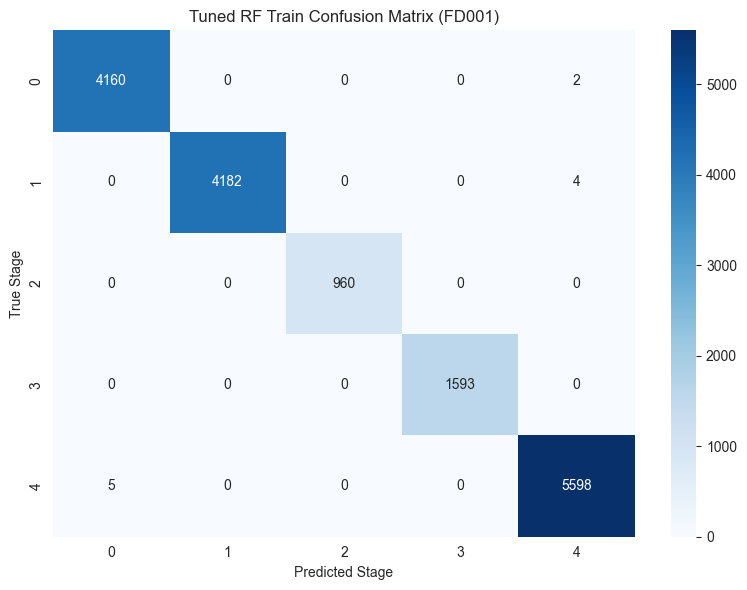

✅ Saved: file://c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix_tuned_smote_roll.png


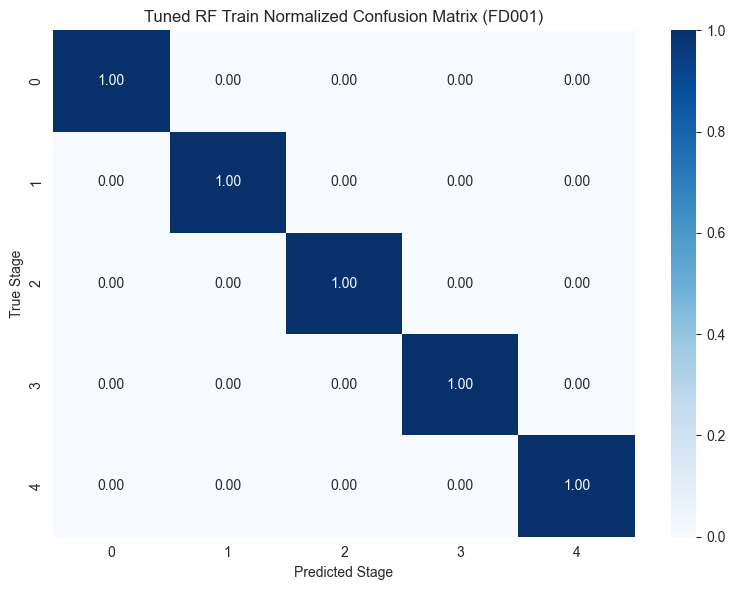

✅ Saved: file://c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png


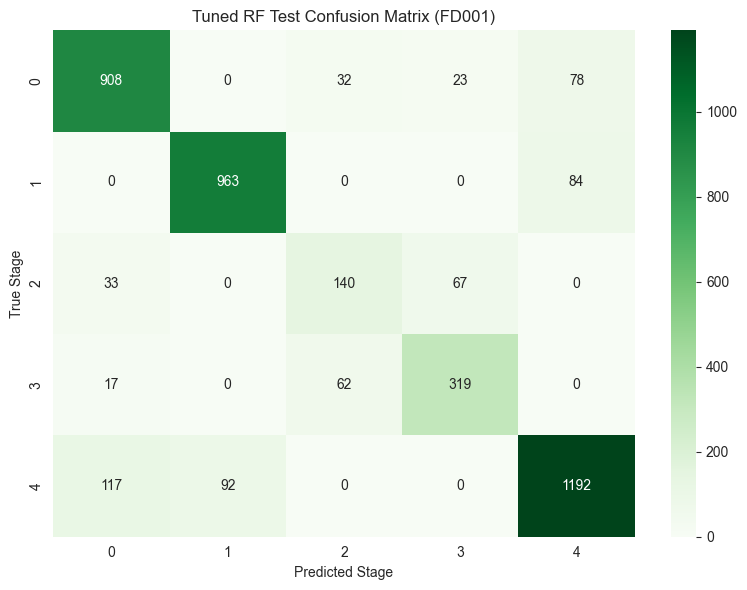

✅ Saved: file://c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix_tuned_smote_roll.png


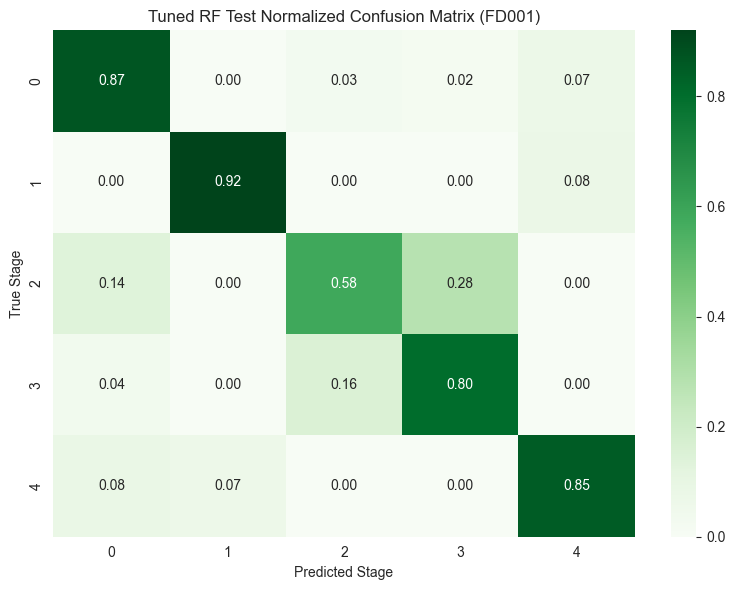

✅ Saved: file://c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png


In [ ]:
# Phase 3 (FD001) – Step B: Evaluation (Tuned RF with SMOTE + Rolling)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Predict
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# 2. Accuracy
print(f" RF Tuned Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f" RF Tuned Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")

# 3. Save Classification Reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

train_report_path = os.path.join(report_dir, 'rf_fd001_train_classification_report_tuned_with_smote_roll.txt')
test_report_path = os.path.join(report_dir, 'rf_fd001_test_classification_report_tuned_with_smote_roll.txt')

with open(train_report_path, 'w') as f:
    f.write(classification_report(y_train, y_train_pred))
with open(test_report_path, 'w') as f:
    f.write(classification_report(y_test, y_test_pred))

print(f" Classification report saved:\n📄 Train → file://{train_report_path}\n📄 Test  → file://{test_report_path}")

# 4. Save Confusion Matrices
fig_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(fig_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    path = os.path.join(fig_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f" Saved: file://{path}")

# 5. Train Confusion Matrices
save_conf_matrix(confusion_matrix(y_train, y_train_pred), 
                 "Tuned RF Train Confusion Matrix (FD001)", 
                 "rf_fd001_train_conf_matrix_tuned_smote_roll.png", 'd', 'Blues')
save_conf_matrix(confusion_matrix(y_train, y_train_pred, normalize='true'), 
                 "Tuned RF Train Normalized Confusion Matrix (FD001)", 
                 "rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Blues')

# 6. Test Confusion Matrices
save_conf_matrix(confusion_matrix(y_test, y_test_pred), 
                 "Tuned RF Test Confusion Matrix (FD001)", 
                 "rf_fd001_test_conf_matrix_tuned_smote_roll.png", 'd', 'Greens')
save_conf_matrix(confusion_matrix(y_test, y_test_pred, normalize='true'), 
                 "Tuned RF Test Normalized Confusion Matrix (FD001)", 
                 "rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Greens')


# Step C: Confusion Matrix Plotting and Saving

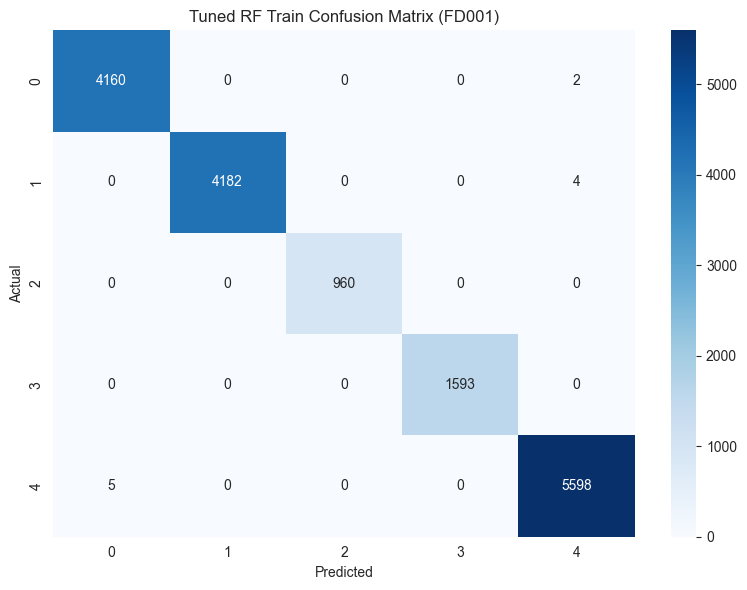

✅ Saved: ..\..\figures\phase3\rf_fd001_train_conf_matrix_tuned_smote_roll.png


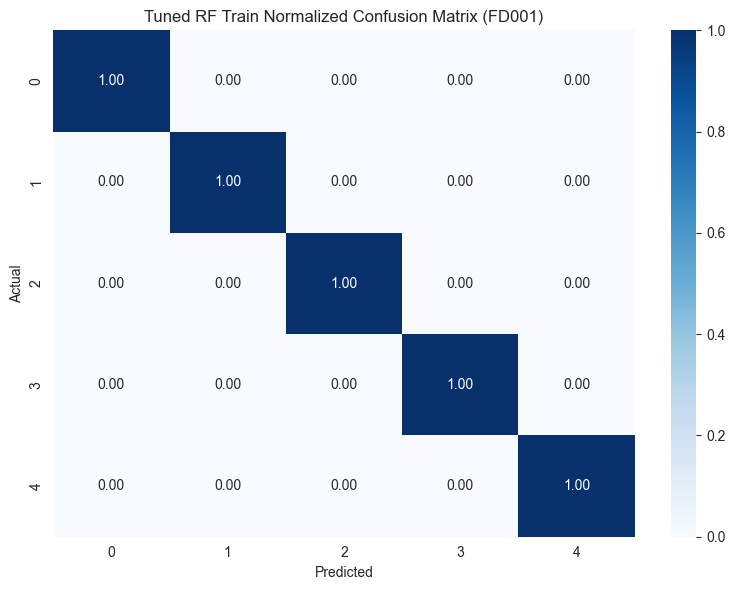

✅ Saved: ..\..\figures\phase3\rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png


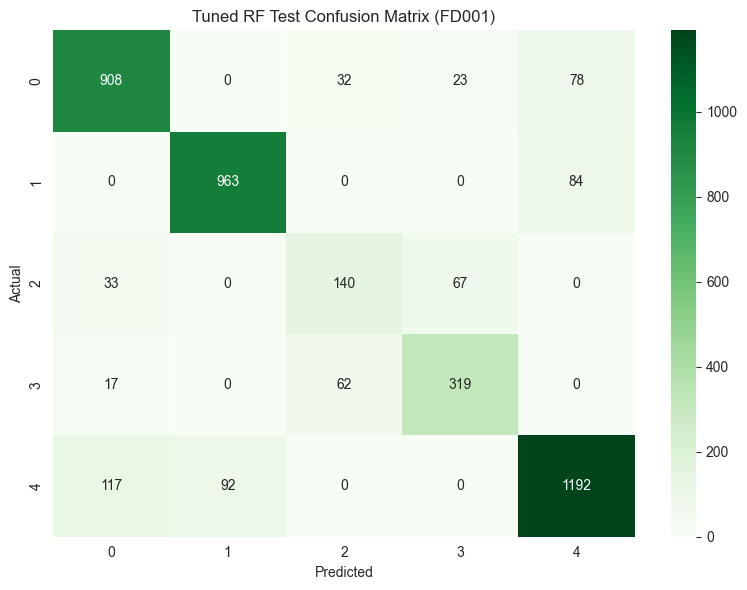

✅ Saved: ..\..\figures\phase3\rf_fd001_test_conf_matrix_tuned_smote_roll.png


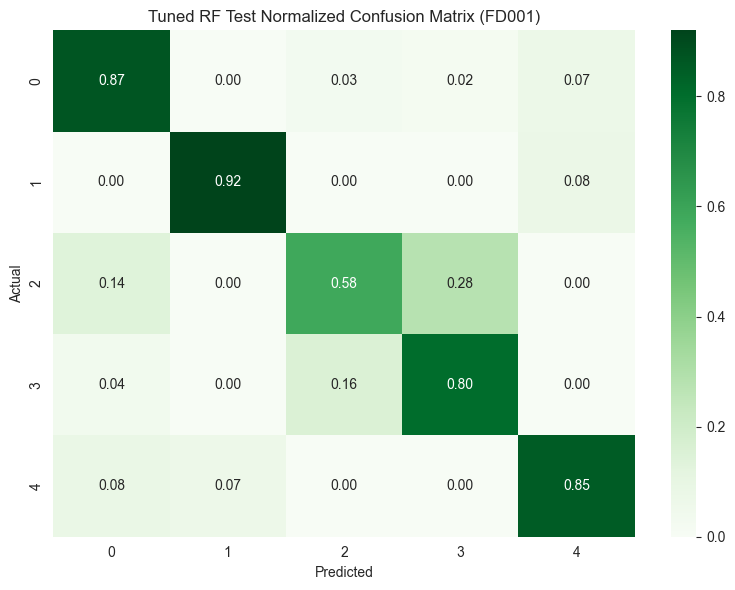

✅ Saved: ..\..\figures\phase3\rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png


In [ ]:
# Step C: Confusion Matrix Plotting and Saving

import matplotlib.pyplot as plt
import seaborn as sns

# 13. Confusion Matrix Plot Utility
def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    fig_path = os.path.join('..', '..', 'figures', 'phase3', filename)
    plt.savefig(fig_path)
    plt.show()
    print(f" Saved: {fig_path}")

# 14. Plot Train and Test Matrices
save_conf_matrix(confusion_matrix(y_train, y_train_pred),
                 "Tuned RF Train Confusion Matrix (FD001)",
                 "rf_fd001_train_conf_matrix_tuned_smote_roll.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train, y_train_pred, normalize='true'),
                 "Tuned RF Train Normalized Confusion Matrix (FD001)",
                 "rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test, y_test_pred),
                 "Tuned RF Test Confusion Matrix (FD001)",
                 "rf_fd001_test_conf_matrix_tuned_smote_roll.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test, y_test_pred, normalize='true'),
                 "Tuned RF Test Normalized Confusion Matrix (FD001)",
                 "rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Greens')


# Final Step: Model Comparison Table + Bar Plot


✅ Model Comparison Table saved at:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase3_model_comparison_fd001_final.csv


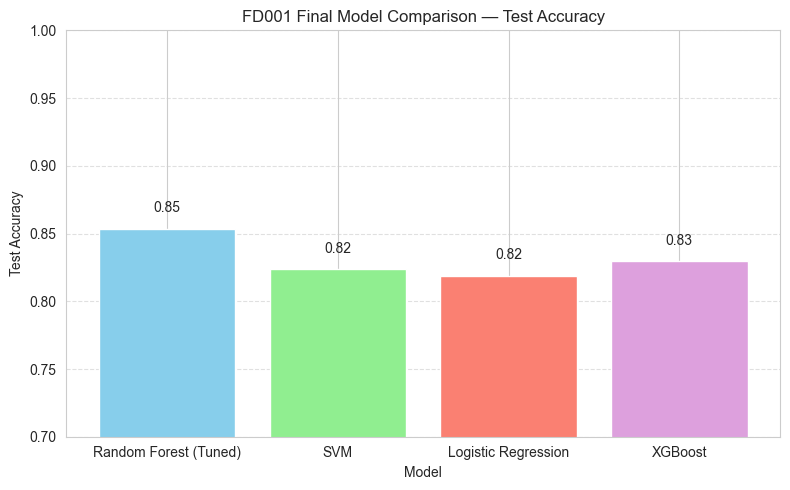

✅ Bar Plot saved at:
c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\model_comparison_test_accuracy_fd001_final.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define final evaluation results for FD001
model_comparison_fd001 = {
    'Model': ['Random Forest (Tuned)', 'SVM', 'Logistic Regression', 'XGBoost'],
    'Train Accuracy': [
        0.9993,     # RF (Tuned + SMOTE + Rolling)
        0.8288,     # SVM
        0.8210,     # Logistic Regression
        0.8897      # XGBoost
    ],
    'Test Accuracy': [
        0.8534,     # RF Tuned
        0.8238,     # SVM
        0.8190,     # Logistic Regression
        0.8294      # XGBoost
    ],
    'Mean F1 Macro Score (CV)': [
        0.8086,     # RF
        0.7508,     # SVM
        0.7499,     # LR
        0.7428      # XGB
    ]
}

# Create DataFrame
df = pd.DataFrame(model_comparison_fd001)

# Create folders relative to current directory
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
report_dir = os.path.join(base_dir, 'report')
figures_dir = os.path.join(base_dir, 'figures', 'phase3')
os.makedirs(report_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Save the comparison table
table_path = os.path.join(report_dir, 'phase3_model_comparison_fd001_final.csv')
df.to_csv(table_path, index=False)
print(f"\n Model Comparison Table saved at:\n{os.path.abspath(table_path)}")

# Bar Plot: Test Accuracy
plt.figure(figsize=(8, 5))
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']
bars = plt.bar(df['Model'], df['Test Accuracy'], color=colors)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01,
             f'{height:.2f}', ha='center', va='bottom')

plt.ylim(0.7, 1.0)
plt.title('FD001 Final Model Comparison — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plot_path = os.path.join(figures_dir, 'model_comparison_test_accuracy_fd001_final.png')
plt.savefig(plot_path)
plt.show()
print(f" Bar Plot saved at:\n{os.path.abspath(plot_path)}")
